In [ ]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [7]:
# aggregate monthly, re-analyse based on percentage of total jobs, ploit monthly skill demand
df_DA_GER = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()
df_DA_GER['job_posted_month_no'] = df_DA_GER['job_posted_date'].dt.month
df_DA_GER_explode = df_DA_GER.explode('job_skills')

df_DA_GER_piv = df_DA_GER_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_GER_piv.loc['Total'] = df_DA_GER_piv.sum()
df_DA_GER_piv = df_DA_GER_piv[df_DA_GER_piv.loc['Total'].sort_values(ascending=False).index]
df_DA_GER_piv = df_DA_GER_piv.drop('Total')

DA_totals = df_DA_GER.groupby('job_posted_month_no').size()

df_DA_GER_perc = df_DA_GER_piv.div(DA_totals / 100, axis=0)
df_DA_GER_perc = df_DA_GER_perc.reset_index()
df_DA_GER_perc['job_posted_month'] = df_DA_GER_perc['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_GER_perc = df_DA_GER_perc.set_index('job_posted_month')
df_DA_GER_perc = df_DA_GER_perc.drop(columns='job_posted_month_no')
df_DA_GER_perc

job_skills,sql,python,tableau,excel,power bi,r,sap,azure,sas,qlik,...,golang,rust,puppet,tidyr,symphony,svn,webex,watson,vue.js,yarn
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,41.442953,35.906040,23.322148,17.617450,15.100671,19.798658,9.060403,6.040268,6.711409,3.523490,...,0.000000,0.000000,0.000000,0.000000,0.167785,0.000000,0.167785,0.000000,0.167785,0.167785
Feb,40.472175,31.871838,22.765599,23.102867,20.404722,14.502530,11.129848,6.576728,5.733558,5.396290,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,43.642612,30.240550,18.041237,18.556701,19.415808,16.666667,8.247423,7.731959,6.872852,3.780069,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,47.577093,34.361233,22.026432,18.502203,21.145374,19.162996,9.691630,5.506608,4.405286,3.964758,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,43.488372,34.883721,22.093023,20.930233,19.767442,15.581395,7.906977,9.069767,5.116279,6.046512,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,41.935484,33.333333,18.458781,16.666667,18.458781,15.412186,9.677419,6.630824,5.376344,3.942652,...,0.000000,0.000000,0.000000,0.179211,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,45.321101,38.532110,18.899083,17.431193,18.165138,20.000000,9.357798,5.137615,6.605505,5.137615,...,0.000000,0.183486,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,44.376278,31.288344,19.836401,16.564417,19.222904,17.177914,10.429448,7.566462,3.271984,3.680982,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.204499,0.000000,0.000000,0.000000,0.000000
Sep,37.804878,29.878049,17.225610,14.786585,16.920732,16.615854,8.841463,6.402439,4.268293,4.420732,...,0.152439,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


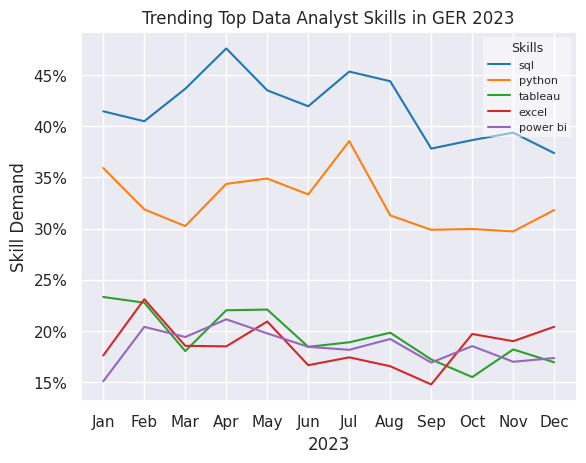

In [53]:
df_plot = df_DA_GER_perc.iloc[:, :5]
sns.set_theme(style='darkgrid')
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
plt.title('Trending Top Data Analyst Skills in GER 2023')
plt.xlabel(2023)
plt.ylabel('Skill Demand')
plt.legend(
    title="Skills",
    loc="upper right",
    frameon=True,
    framealpha=0.5,
    facecolor="white",
    edgecolor="none",
    fontsize=8,
    title_fontsize=9
)
ax = plt.gca()

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

